In [42]:
import pandas as pd
import numpy as np

import nltk
import re

from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
!pip install nltk

In [44]:
import nltk
print(nltk.__version__)

3.10.0


In [45]:
import nltk

nltk.download("vader_lexicon")
nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [46]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

print(sia.polarity_scores("This product is amazing!"))

{'neg': 0.0, 'neu': 0.423, 'pos': 0.577, 'compound': 0.6239}


In [47]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dongrelaxman/amazon-reviews-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\dongrelaxman\amazon-reviews-dataset\versions\1


In [48]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [49]:
import pandas as pd

df = pd.read_csv("Amazon_Reviews.csv", engine="python")

df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [50]:
df.info()

print(df.columns)

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Reviewer Name       21214 non-null  str  
 1   Profile Link        21163 non-null  str  
 2   Country             21054 non-null  str  
 3   Review Count        21055 non-null  str  
 4   Review Date         21055 non-null  str  
 5   Rating              21055 non-null  str  
 6   Review Title        21055 non-null  str  
 7   Review Text         21055 non-null  str  
 8   Date of Experience  20947 non-null  str  
dtypes: str(9)
memory usage: 1.5 MB
Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='str')


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [51]:
print(df.columns)

Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='str')


In [52]:
df.isna().sum()

Reviewer Name           0
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          159
Review Text           159
Date of Experience    267
dtype: int64

In [53]:
df = df.dropna(subset=["Review Text"])

df.shape

(21055, 9)

In [54]:
df.isna().sum()

Reviewer Name           0
Profile Link            0
Country                 1
Review Count            0
Review Date             0
Rating                  0
Review Title            0
Review Text             0
Date of Experience    108
dtype: int64

In [55]:
df["Rating"].value_counts().sort_index()

Rating
Rated 1 out of 5 stars    13123
Rated 2 out of 5 stars     1227
Rated 3 out of 5 stars      885
Rated 4 out of 5 stars     1292
Rated 5 out of 5 stars     4528
Name: count, dtype: int64

In [56]:
df["Rating"] = df["Rating"].str.extract(r"(\d)").astype(int)

In [57]:
df["Rating"].head()

0    1
1    1
2    1
3    1
4    1
Name: Rating, dtype: int64

In [58]:
df["Rating"].head(10)

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    5
8    1
9    5
Name: Rating, dtype: int64

In [59]:
df["Rating"].value_counts().sort_index()

Rating
1    13123
2     1227
3      885
4     1292
5     4528
Name: count, dtype: int64

In [60]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df["Compound Score"] = df["Review Text"].apply(
    lambda text: sia.polarity_scores(str(text))["compound"]
)

In [61]:
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Compound Score"].apply(classify_sentiment)

In [62]:
df[["Review Text", "Rating", "Compound Score", "Sentiment"]].head()

,Review Text,Rating,Compound Score,Sentiment
0,"I registered on the website, tried to order a ...",1,0.8432,Positive
1,Had multiple orders one turned up and driver h...,1,-0.7096,Negative
2,I informed these reprobates that I WOULD NOT B...,1,-0.9276,Negative
3,I have bought from Amazon before and no proble...,1,-0.8947,Negative
4,If I could give a lower rate I would! I cancel...,1,-0.7327,Negative


In [63]:
df["Sentiment"].value_counts()

Sentiment
Positive    10284
Negative     9296
Neutral      1475
Name: count, dtype: int64

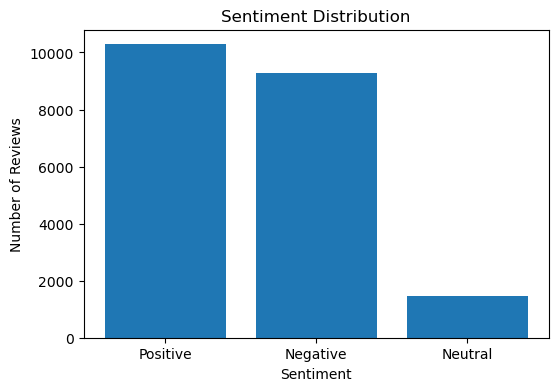

In [64]:
import matplotlib.pyplot as plt

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [65]:
pd.crosstab(df["Rating"], df["Sentiment"])

Sentiment,Negative,Neutral,Positive
Rating,,,
1,7998,608,4517
2,595,84,548
3,307,107,471
4,148,166,978
5,248,510,3770


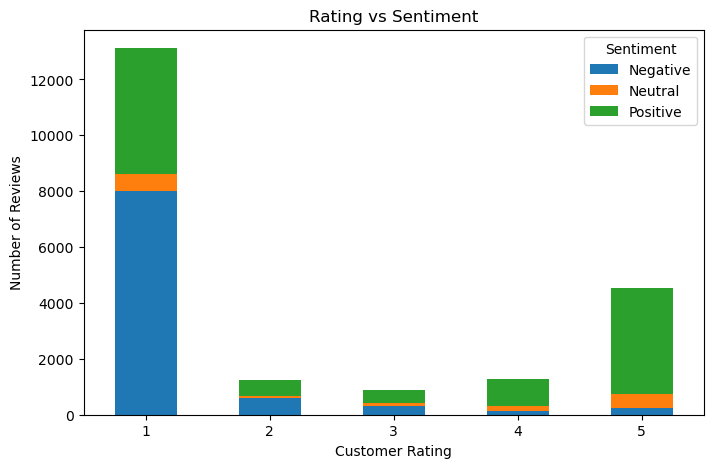

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

cross_tab = pd.crosstab(df["Rating"], df["Sentiment"])

cross_tab.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Rating vs Sentiment")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

In [67]:
df.to_csv("Amazon_Reviews_Cleaned.csv", index=False)

In [68]:
import os

print(os.getcwd())

C:\Users\USER\warning


In [69]:
df.to_csv("Amazon_Reviews_Sentiment_Analysis.csv", index=False)

In [70]:
%pip install transformers torch

Note: you may need to restart the kernel to use updated packages.


In [71]:
from transformers import pipeline

In [72]:
sample_review = df["Review Text"].iloc[0]

result = emotion_classifier(sample_review[:512])

print(result)

[[{'label': 'fear', 'score': 0.7773471474647522}]]


In [73]:
from transformers import pipeline

emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=1
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [74]:
sample_review = df["Review Text"].iloc[0]

result = emotion_classifier(sample_review[:512])

print(result)

[[{'label': 'fear', 'score': 0.7773471474647522}]]


In [75]:
def detect_emotion(text):
    result = emotion_classifier(str(text)[:512])
    return result[0][0]["label"]

In [76]:
sample_df = df.head(100).copy()

sample_df["Emotion"] = sample_df["Review Text"].apply(detect_emotion)

sample_df[["Review Text", "Sentiment", "Emotion"]].head()

,Review Text,Sentiment,Emotion
0,"I registered on the website, tried to order a ...",Positive,fear
1,Had multiple orders one turned up and driver h...,Negative,fear
2,I informed these reprobates that I WOULD NOT B...,Negative,fear
3,I have bought from Amazon before and no proble...,Negative,sadness
4,If I could give a lower rate I would! I cancel...,Negative,anger


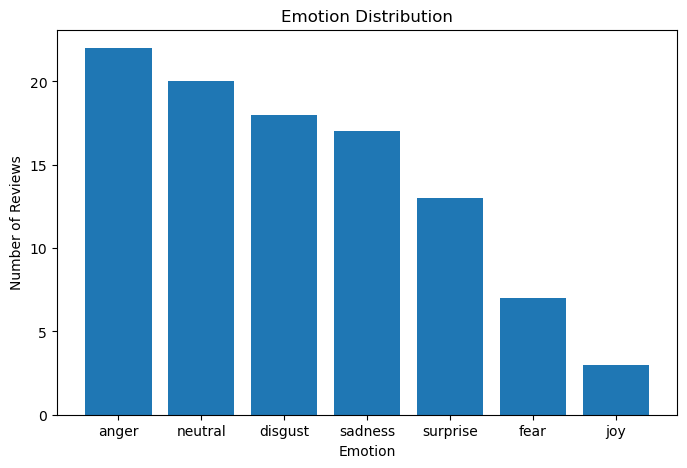

In [78]:
import matplotlib.pyplot as plt

emotion_counts = sample_df["Emotion"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(emotion_counts.index, emotion_counts.values)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")

plt.show()

In [79]:
df.to_csv("Amazon_Reviews_Sentiment_Emotion.csv", index=False)